# <center> Практика. Статистические тесты в контексте EDA

## Постановка задачи

HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.

HR-агентство хочет ответить на следующие вопросы:

- Размер страховых выплат для клиентов-мужчин больше, чем для клиентов-женщин?
- Размер страховых выплат для некурящих клиентов меньше, чем для курящих?
- Влияет ли регион проживания на размер выплат?
- Есть ли взаимосвязь между курением и полом?

На каждый вопрос необходимо ответить с уровнем значимости $\alpha=0.05$.

## Загрузка данных

In [1]:
# загружаем необходимые библиотеки
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns

# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.set_palette("Set2")

In [2]:
# загружаем датасет
data = pd.read_csv(r"C:\Users\aleks\Downloads\asset-v1_SkillFactory+DST-3.0+28FEB2021+type@asset+block@ds_salaries\ds_salaries.csv")
data.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


## Описательный анализ данных

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


В датасете 607 записей (без пропущенных значений).

Проверим данные на наличие полных дубликатов:

In [5]:
print('Количество дубликатов: {}'.format(data[data.duplicated()].shape[0]))

# Удаляем дубликаты:
data = data.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(data.shape))

Количество дубликатов: 0
Размер таблицы после удаления дубликатов: (607, 12)


### Распределение зарплат 

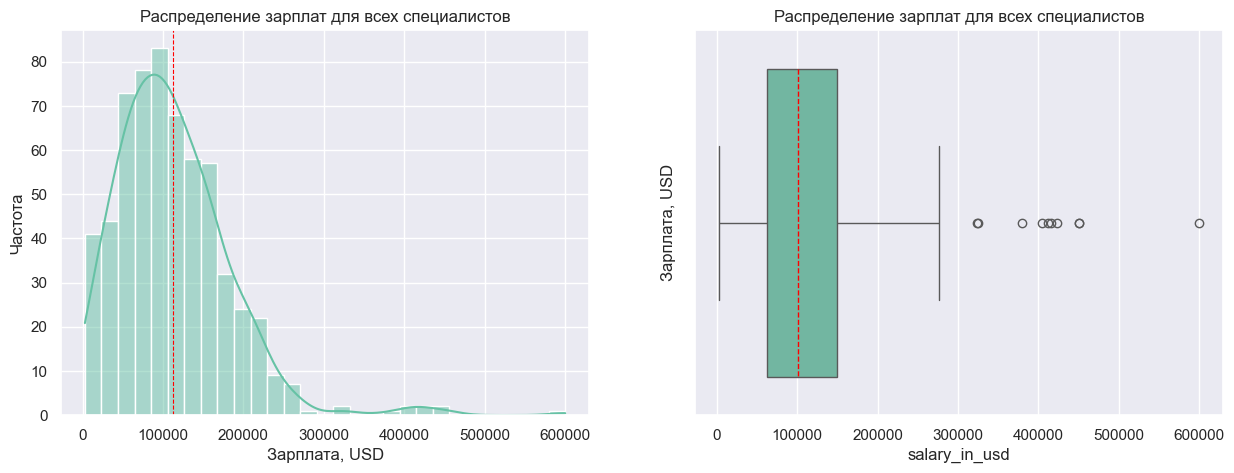

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма зарплат
sns.histplot(data['salary_in_usd'], kde=True, ax=axes[0])
axes[0].set(xlabel='Зарплата, USD', ylabel='Частота')
axes[0].set_title('Распределение зарплат для всех специалистов')
axes[0].axvline(data['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

# Boxplot зарплат
sns.boxplot(data['salary_in_usd'], ax=axes[1], orient='h',
            medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='Зарплата, USD')
axes[1].set_title('Распределение зарплат для всех специалистов')

plt.show()

In [11]:
data_agg = data['salary_in_usd'].describe().round(2).to_frame()
data_agg.columns = ['Зарплата в USD']
data_agg

,Зарплата в USD
count,607.00
mean,112297.87
std,70957.26
min,2859.00
25%,62726.00
50%,101570.00
75%,150000.00
max,600000.00


### Распределение зарплат для Data Scientist и Data Engineer

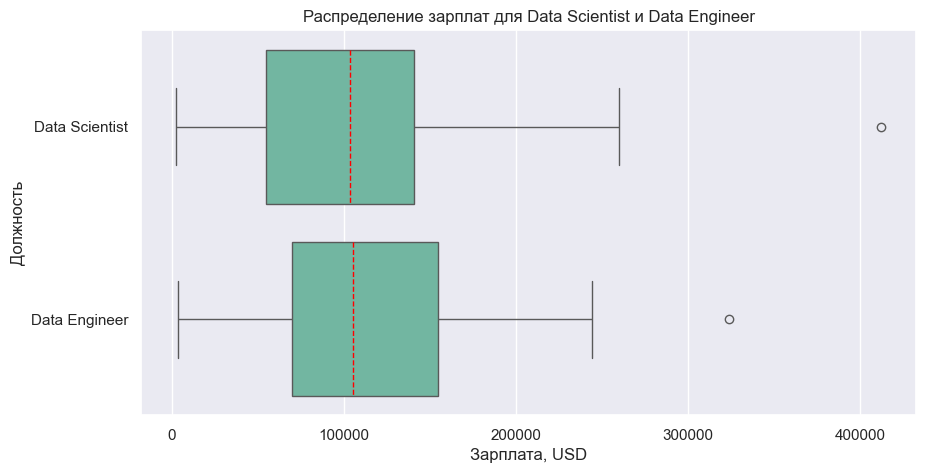

In [13]:
data_roles = data[data['job_title'].isin(['Data Scientist', 'Data Engineer'])]

plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=data_roles, x='salary_in_usd', y='job_title',
                 orient='h',
                 medianprops={"color": "red", "linestyle": '--'})

ax.set(xlabel='Зарплата, USD', ylabel='Должность')
plt.title('Распределение зарплат для Data Scientist и Data Engineer')

plt.show()

In [12]:
data_agg = data[data['job_title'].isin(['Data Scientist', 'Data Engineer'])].groupby('job_title')['salary_in_usd'].describe().round(2)
data_agg

,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
Data Engineer,132.0,112725.00,57629.08,4000.0,70039.5,105500.0,154600.0,324000.0
Data Scientist,143.0,108187.83,64112.84,2859.0,54724.0,103691.0,140850.0,412000.0


По всем данным видно, что медианная зарплата Data Engineer немного выше, чем у Data Scientist. Средняя зарплата также выше у Data Engineer. При этом разброс зарплат в обеих группах достаточно большой, а у Data Scientist наблюдается более высокий максимум, что указывает на наличие отдельных очень высоких значений. Визуально различия между группами не выглядят резкими, поэтому для окончательного вывода требуется статистическая проверка.

### Факторы влияющие на зарплату специалиста Data Scientist 

#### По опыту

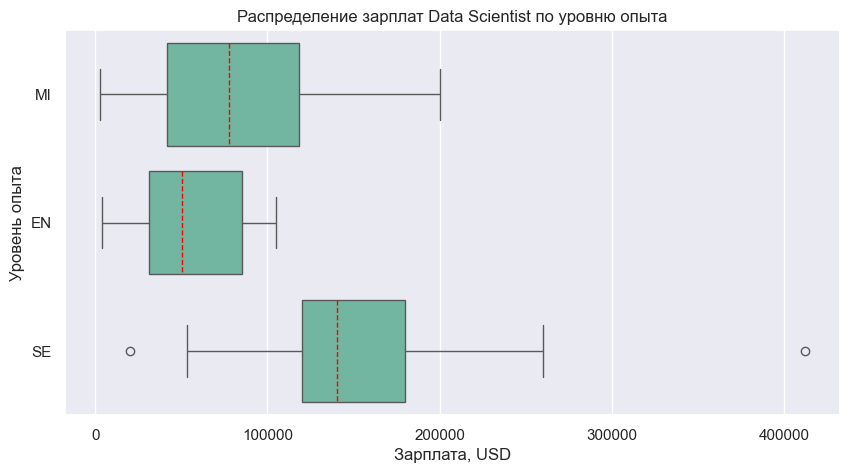

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[data['job_title'] == 'Data Scientist'],
            x='salary_in_usd', y='experience_level',
            orient='h',
            medianprops={"color": "red", "linestyle": '--'})
plt.xlabel('Зарплата, USD')
plt.ylabel('Уровень опыта')
plt.title('Распределение зарплат Data Scientist по уровню опыта')
plt.show()

In [16]:
data_agg = data[data['job_title'] == 'Data Scientist'].groupby('experience_level')['salary_in_usd'].describe().round(2)
data_agg

,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,22.0,55330.91,31237.82,4000.0,31474.0,50483.5,85027.25,105000.0
MI,60.0,82039.13,46869.58,2859.0,41768.0,77479.0,118264.75,200000.0
SE,61.0,152971.02,58985.40,20171.0,120000.0,140400.0,180000.00,412000.0


С увеличением уровня опыта зарплата Data Scientist заметно растёт: у SE значения существенно выше, чем у MI и EN, что указывает на сильную связь между опытом и оплатой труда.

#### По размеру компании

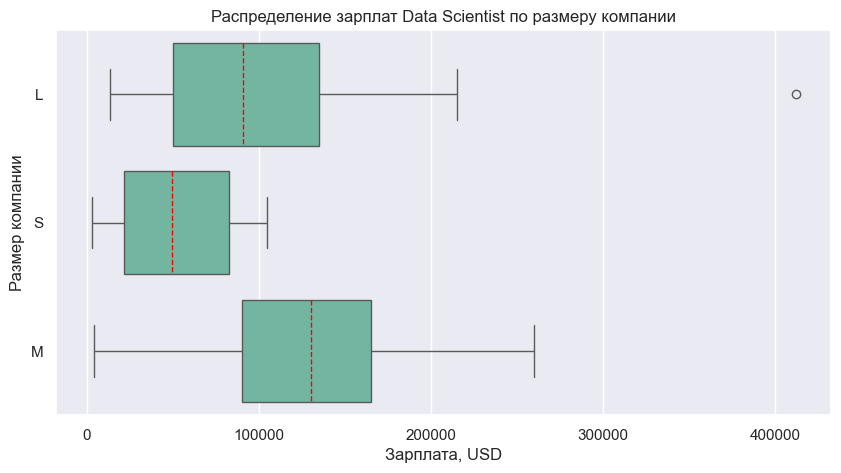

In [17]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[data['job_title'] == 'Data Scientist'],
            x='salary_in_usd', y='company_size',
            orient='h',
            medianprops={"color": "red", "linestyle": '--'})
plt.xlabel('Зарплата, USD')
plt.ylabel('Размер компании')
plt.title('Распределение зарплат Data Scientist по размеру компании')
plt.show()

In [18]:
data_agg = data[data['job_title'] == 'Data Scientist'].groupby('company_size')['salary_in_usd'].describe().round(2)
data_agg

,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
L,45.0,103313.36,71815.18,13400.0,50000.0,90734.0,135000.0,412000.0
M,77.0,126380.75,56389.53,4000.0,90000.0,130000.0,165000.0,260000.0
S,21.0,51925.76,33216.29,2859.0,21669.0,49268.0,82500.0,105000.0


Зарплаты Data Scientist выше в средних и крупных компаниях по сравнению с малыми, что может указывать на связь между размером компании и уровнем оплаты труда.

#### По году

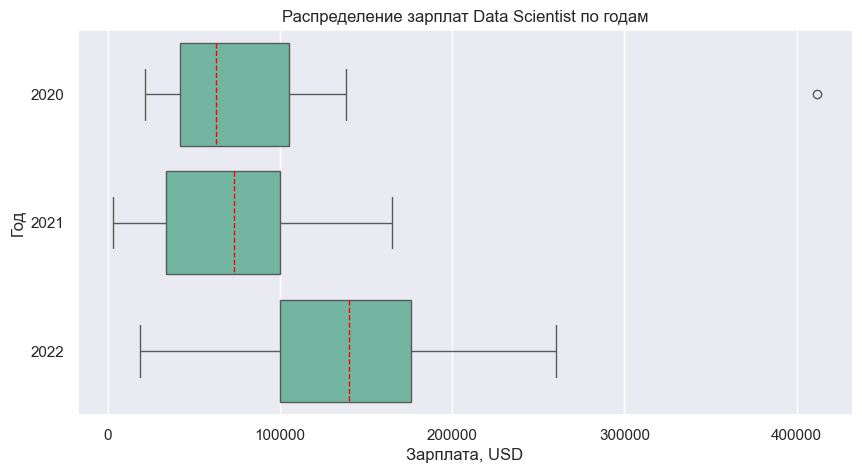

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[data['job_title'] == 'Data Scientist'],
            x='salary_in_usd', y='work_year',
            orient='h',
            medianprops={"color": "red", "linestyle": '--'})
plt.xlabel('Зарплата, USD')
plt.ylabel('Год')
plt.title('Распределение зарплат Data Scientist по годам')
plt.show()

In [20]:
data_agg = data[data['job_title'] == 'Data Scientist'].groupby('work_year')['salary_in_usd'].describe().round(2)
data_agg

,count,mean,std,min,25%,50%,75%,max
work_year,,,,,,,,
2020,21.0,85970.52,81436.65,21669.0,42197.0,62726.0,105000.0,412000.0
2021,45.0,70671.73,45422.97,2859.0,33808.0,73000.0,100000.0,165000.0
2022,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


В 2022 году зарплаты Data Scientist выше, чем в 2020 и 2021 годах, что может указывать на рост уровня оплаты труда по годам.

#### По общему объёму работы, выполняемой удалённо

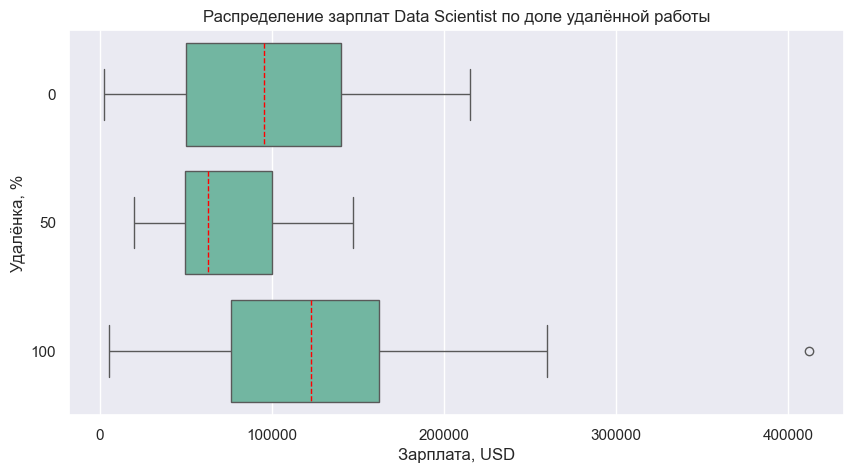

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[data['job_title'] == 'Data Scientist'],
            x='salary_in_usd', y='remote_ratio',
            orient='h',
            medianprops={"color": "red", "linestyle": '--'})
plt.xlabel('Зарплата, USD')
plt.ylabel('Удалёнка, %')
plt.title('Распределение зарплат Data Scientist по доле удалённой работы')
plt.show()

In [22]:
data_agg = data[data['job_title'] == 'Data Scientist'].groupby('remote_ratio')['salary_in_usd'].describe().round(2)
data_agg

,count,mean,std,min,25%,50%,75%,max
remote_ratio,,,,,,,,
0,39.0,99520.74,58259.42,2859.0,50294.5,95550.0,140400.0,215300.0
50,25.0,74504.08,35602.82,20171.0,49646.0,62726.0,100000.0,147000.0
100,79.0,123125.94,69370.99,5679.0,76366.0,123000.0,162500.0,412000.0


По данным видно, что полностью удалённые позиции (remote_ratio = 100) в среднем оплачиваются выше, чем частично удалённые и офисные. Это может указывать на связь между форматом работы и уровнем зарплаты Data Scientist.

#### Общий вывод 

По результатам описательной статистики видно, что зарплата Data Scientist заметно зависит от уровня опыта, размера компании, года наблюдения и доли удалённой работы. Наиболее высокие значения зарплат наблюдаются у специалистов уровня SE: медиана и среднее у этой группы значительно выше, чем у MI и особенно EN. Также более высокие зарплаты характерны для крупных и средних компаний по сравнению с малыми. По годам видно, что в 2022 году зарплаты выше, чем в 2020–2021 годах, что может указывать на рост рынка. Кроме того, полностью удалённые позиции (remote_ratio = 100) в среднем оплачиваются выше, чем гибридные и офисные.

### Ключевые вопросы HR-агентства: 

#### Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?

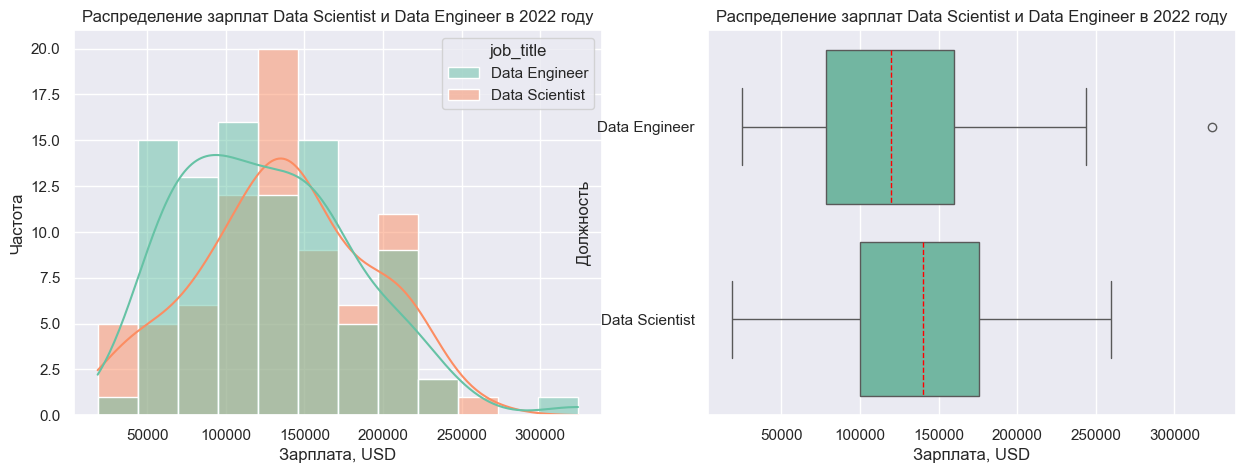

In [25]:
data_2022 = data[(data['work_year'] == 2022) & (data['job_title'].isin(['Data Scientist', 'Data Engineer']))]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=data_2022, x='salary_in_usd', hue='job_title', kde=True, ax=axes[0])
axes[0].set(xlabel='Зарплата, USD', ylabel='Частота')
axes[0].set_title('Распределение зарплат Data Scientist и Data Engineer в 2022 году')

sns.boxplot(data=data_2022, x='salary_in_usd', y='job_title', orient='h',
            ax=axes[1], medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Зарплата, USD', ylabel='Должность')
axes[1].set_title('Распределение зарплат Data Scientist и Data Engineer в 2022 году')

plt.show()

In [26]:
data_agg = data[(data['work_year'] == 2022) & (data['job_title'].isin(['Data Scientist', 'Data Engineer']))] \
    .groupby('job_title')['salary_in_usd'].describe().round(2)
data_agg

,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
Data Engineer,89.0,126375.70,55954.40,25000.0,78526.0,120000.0,160000.0,324000.0
Data Scientist,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


В 2022 году зарплаты Data Scientist немного выше, чем у Data Engineer: и среднее, и медиана у Data Scientist больше. При этом различия не выглядят очень большими, поэтому для подтверждения вывода нужна статистическая проверка.

#### Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

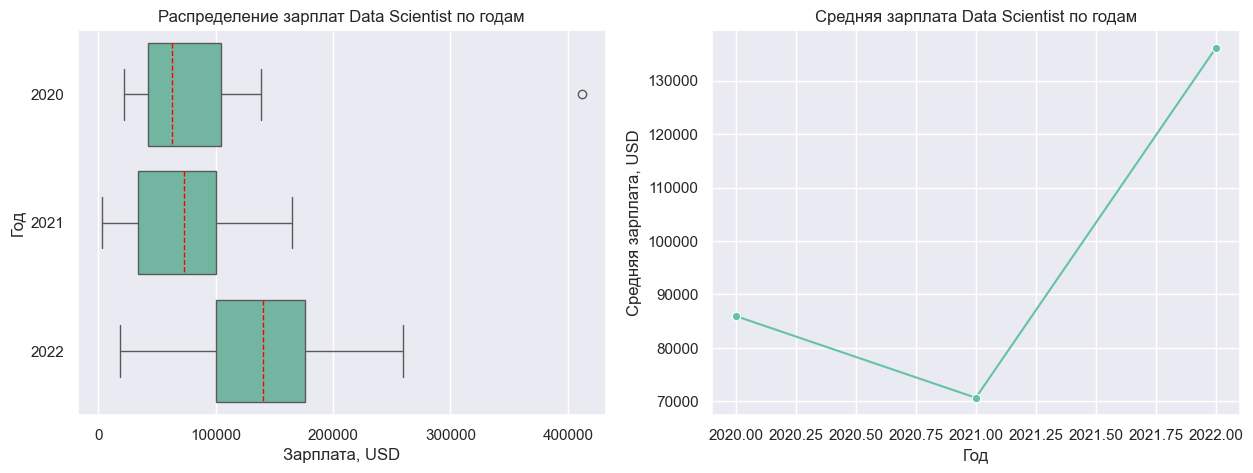

In [27]:
data_year = data[data['job_title'] == 'Data Scientist']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=data_year, x='salary_in_usd', y='work_year',
            orient='h', ax=axes[0],
            medianprops={"color": "red", "linestyle": '--'})
axes[0].set(xlabel='Зарплата, USD', ylabel='Год')
axes[0].set_title('Распределение зарплат Data Scientist по годам')

sns.lineplot(data=data_year.groupby('work_year', as_index=False)['salary_in_usd'].mean(),
             x='work_year', y='salary_in_usd', marker='o', ax=axes[1])
axes[1].set(xlabel='Год', ylabel='Средняя зарплата, USD')
axes[1].set_title('Средняя зарплата Data Scientist по годам')

plt.show()

In [28]:
data_agg = data[data['job_title'] == 'Data Scientist'].groupby('work_year')['salary_in_usd'].describe().round(2)
data_agg

,count,mean,std,min,25%,50%,75%,max
work_year,,,,,,,,
2020,21.0,85970.52,81436.65,21669.0,42197.0,62726.0,105000.0,412000.0
2021,45.0,70671.73,45422.97,2859.0,33808.0,73000.0,100000.0,165000.0
2022,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


В 2022 году зарплаты Data Scientist заметно выше, чем в 2020 и 2021 годах, что может указывать на общий рост уровня оплаты труда по годам.

#### Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

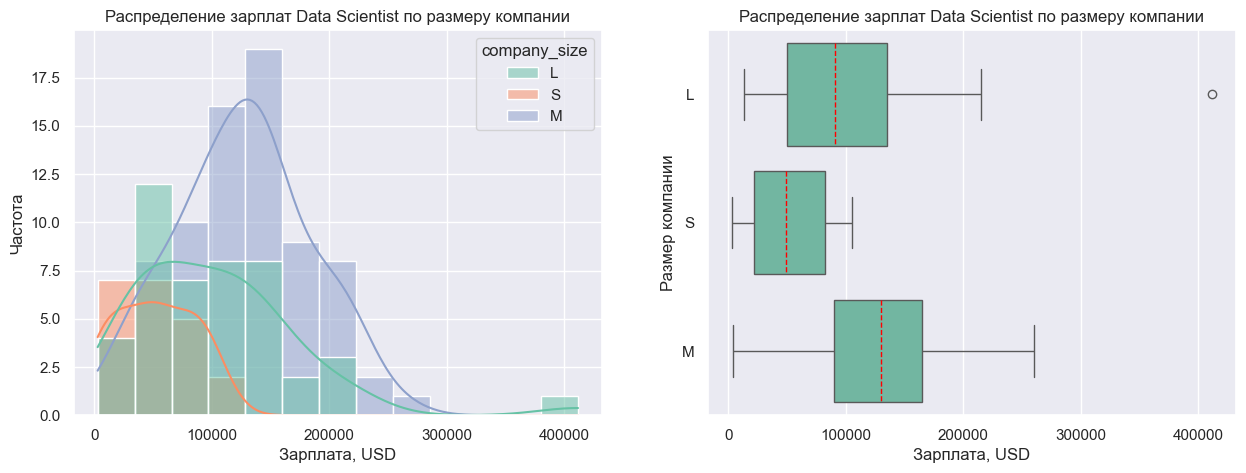

In [29]:
data_ds = data[data['job_title'] == 'Data Scientist']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=data_ds, x='salary_in_usd', hue='company_size', kde=True, ax=axes[0])
axes[0].set(xlabel='Зарплата, USD', ylabel='Частота')
axes[0].set_title('Распределение зарплат Data Scientist по размеру компании')

sns.boxplot(data=data_ds, x='salary_in_usd', y='company_size', orient='h',
            ax=axes[1], medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Зарплата, USD', ylabel='Размер компании')
axes[1].set_title('Распределение зарплат Data Scientist по размеру компании')

plt.show()

In [30]:
data_agg = data[data['job_title'] == 'Data Scientist'].groupby('company_size')['salary_in_usd'].describe().round(2)
data_agg

,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
L,45.0,103313.36,71815.18,13400.0,50000.0,90734.0,135000.0,412000.0
M,77.0,126380.75,56389.53,4000.0,90000.0,130000.0,165000.0,260000.0
S,21.0,51925.76,33216.29,2859.0,21669.0,49268.0,82500.0,105000.0


Зарплаты Data Scientist выше в средних и крупных компаниях, чем в малых, при этом максимальные значения и медианы заметно выше у компаний размера M и L.

#### Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании? 

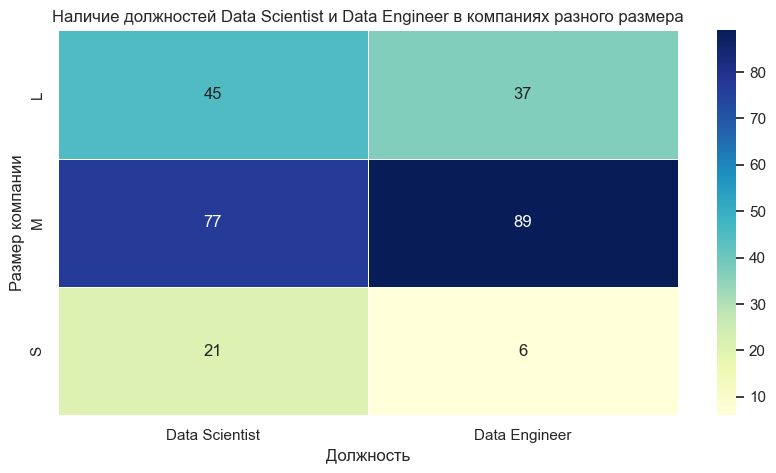

In [31]:
cross_tab = pd.crosstab(data['company_size'], data['job_title'])[['Data Scientist', 'Data Engineer']]

plt.figure(figsize=(10, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.xlabel('Должность')
plt.ylabel('Размер компании')
plt.title('Наличие должностей Data Scientist и Data Engineer в компаниях разного размера')
plt.show()

In [32]:
data_agg = pd.crosstab(data['company_size'], data['job_title'])[['Data Scientist', 'Data Engineer']]
data_agg

job_title,Data Scientist,Data Engineer
company_size,,
L,45,37
M,77,89
S,21,6


По таблице видно, что и Data Scientist, и Data Engineer встречаются во всех размерах компаний, но чаще всего такие должности представлены в средних и крупных компаниях. Это может указывать на связь между размером компании и наличием этих ролей.

## Статистический анализ данных


In [33]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

#### Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

**Сформулируем нулевую и альтернативные гипотезы**

H0: распределения зарплат Data Scientist в 2020, 2021 и 2022 годах одинаковы.

H1: хотя бы в одном году распределение зарплат отличается.

Будем использовать **критерий Краскела–Уоллиса**

In [37]:
salary_2020 = data[(data['job_title'] == 'Data Scientist') & (data['work_year'] == 2020)]['salary_in_usd']
salary_2021 = data[(data['job_title'] == 'Data Scientist') & (data['work_year'] == 2021)]['salary_in_usd']
salary_2022 = data[(data['job_title'] == 'Data Scientist') & (data['work_year'] == 2022)]['salary_in_usd']

# Проверка нормальности
print('2020:')
decision_normality(stats.shapiro(salary_2020)[1])

print('2021:')
decision_normality(stats.shapiro(salary_2021)[1])

print('2022:')
decision_normality(stats.shapiro(salary_2022)[1])

# Краскел–Уоллис
stat, p = stats.kruskal(salary_2020, salary_2021, salary_2022)
decision_hypothesis(p)

2020:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
2021:
p-value = 0.125
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
2022:
p-value = 0.327
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


##### Вывод 

По результатам проверки распределения зарплаты Data Scientist в 2020 году оно отличается от нормального, а в 2021 и 2022 годах не наблюдается значимых отклонений от нормальности. Критерий Краскела–Уоллиса показал статистически значимые различия между годами, поэтому можно сделать вывод, что зарплаты Data Scientist по годам различаются.

#### Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?

**Сформулируем нулевую и альтернативные гипотезы**

H0: распределения зарплат Data Scientist и Data Engineer в 2022 году одинаковы.

H1: распределения зарплат различаются.

Будем использовать **U-критерий Манна–Уитни**

In [38]:
salary_ds_2022 = data[(data['work_year'] == 2022) & (data['job_title'] == 'Data Scientist')]['salary_in_usd']
salary_de_2022 = data[(data['work_year'] == 2022) & (data['job_title'] == 'Data Engineer')]['salary_in_usd']

print('Data Scientist:')
decision_normality(stats.shapiro(salary_ds_2022)[1])

print('Data Engineer:')
decision_normality(stats.shapiro(salary_de_2022)[1])

stat, p = stats.mannwhitneyu(salary_ds_2022, salary_de_2022, alternative='two-sided')
decision_hypothesis(p)

Data Scientist:
p-value = 0.327
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Data Engineer:
p-value = 0.010
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
p-value = 0.155
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


##### Вывод 

Распределение зарплат Data Scientist в 2022 году не отличается от нормального, а у Data Engineer оно отклоняется от нормального. По тесту Манна–Уитни нет оснований утверждать, что зарплаты этих групп статистически значимо различаются.

#### Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

**Сформулируем нулевую и альтернативные гипотезы**

H0: распределения зарплат Data Scientist в компаниях разных размеров одинаковы.

H1: хотя бы в одной группе распределение отличается.

Будем использовать **критерий Краскела–Уоллиса** и **теста Шапиро–Уилка**

In [43]:
salary_s = data[(data['job_title'] == 'Data Scientist') & (data['company_size'] == 'S')]['salary_in_usd']
salary_m = data[(data['job_title'] == 'Data Scientist') & (data['company_size'] == 'M')]['salary_in_usd']
salary_l = data[(data['job_title'] == 'Data Scientist') & (data['company_size'] == 'L')]['salary_in_usd']

print('S:')
decision_normality(stats.shapiro(salary_s)[1])

print('M:')
decision_normality(stats.shapiro(salary_m)[1])

print('L:')
decision_normality(stats.shapiro(salary_l)[1])

stat, p = stats.kruskal(salary_s, salary_m, salary_l)
decision_hypothesis(p)

S:
p-value = 0.189
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
M:
p-value = 0.639
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
L:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


##### Вывовд 

По результатам теста Шапиро–Уилка распределение зарплат в компаниях размера S и M не отличается от нормального, а в компаниях размера L отличается от нормального. Критерий Краскела–Уоллиса показал статистически значимые различия между группами, значит, зарплаты Data Scientist в компаниях разного размера различаются.

#### Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

**Сформулируем нулевую и альтернативные гипотезы**

H0: размер компании и наличие должностей Data Scientist / Data Engineer независимы.

H1: между размером компании и наличием этих должностей есть связь.

Будем использовать **критерия хи-квадрат Пирсона**

In [44]:
cross_tab = pd.crosstab(data['company_size'], data['job_title'])[['Data Scientist', 'Data Engineer']]
cross_tab

job_title,Data Scientist,Data Engineer
company_size,,
L,45,37
M,77,89
S,21,6


In [47]:
chi2, p, dof, expected = stats.chi2_contingency(cross_tab)

print(f'chi2 = {chi2:.3f}')
print(f'p-value = {p:.3f}')
print(f'dof = {dof}')

chi2 = 9.557
p-value = 0.008
dof = 2


##### Вывод 

По результатам теста хи-квадрат можно сделать вывод, что между размером компании и наличием должностей Data Scientist и Data Engineer есть статистически значимая связь.

## Итоговые результаты исследования

В ходе анализа данных HR‑агентства было установлено, что на зарплату Data Scientist влияют несколько факторов, прежде всего уровень опыта, размер компании, год наблюдения и формат работы. Наиболее высокие зарплаты характерны для специалистов уровня SE, а также для сотрудников средних и крупных компаний.

По годам наблюдается рост зарплат Data Scientist: в 2022 году уровни оплаты труда выше, чем в 2020 и 2021 годах. Также было выявлено, что полностью удалённые позиции в среднем оплачиваются выше, чем частично удалённые и офисные.

Сравнение зарплат Data Scientist и Data Engineer в 2022 году показало, что различия между этими группами есть, но они не выглядят очень большими. При этом зарплаты Data Scientist в компаниях разного размера статистически различаются, а между размером компании и наличием должностей Data Scientist и Data Engineer обнаружена значимая связь.

# Дополнительное исследование

#### Влияние страны компании на зарплату

все страны 

In [48]:
data_agg = data[data['job_title'] == 'Data Scientist'].groupby('company_location')['salary_in_usd'].describe().round(2)
data_agg

,count,mean,std,min,25%,50%,75%,max
company_location,,,,,,,,
AT,2.0,76352.00,21050.57,61467.0,68909.5,76352.0,83794.50,91237.0
AU,1.0,86703.00,NaN,86703.0,86703.0,86703.0,86703.00,86703.0
BR,1.0,12901.00,NaN,12901.0,12901.0,12901.0,12901.00,12901.0
CA,5.0,77787.00,19301.65,52396.0,69336.0,75774.0,87738.00,103691.0
CH,1.0,122346.00,NaN,122346.0,122346.0,122346.0,122346.00,122346.0
CL,1.0,40038.00,NaN,40038.0,40038.0,40038.0,40038.00,40038.0
DE,7.0,69640.14,25045.56,25532.0,55997.0,79833.0,89694.00,90734.0
DZ,1.0,100000.00,NaN,100000.0,100000.0,100000.0,100000.00,100000.0
ES,3.0,41136.67,4935.34,37825.0,38300.5,38776.0,42792.50,46809.0


страны с наибольшим числом наблюдений

In [49]:
top_countries = data[data['job_title'] == 'Data Scientist']['company_location'].value_counts().head(10).index

data_agg = data[
    (data['job_title'] == 'Data Scientist') &
    (data['company_location'].isin(top_countries))
].groupby('company_location')['salary_in_usd'].describe().round(2)

data_agg

,count,mean,std,min,25%,50%,75%,max
company_location,,,,,,,,
AT,2.0,76352.00,21050.57,61467.0,68909.5,76352.0,83794.50,91237.0
CA,5.0,77787.00,19301.65,52396.0,69336.0,75774.0,87738.00,103691.0
DE,7.0,69640.14,25045.56,25532.0,55997.0,79833.0,89694.00,90734.0
ES,3.0,41136.67,4935.34,37825.0,38300.5,38776.0,42792.50,46809.0
FR,7.0,50085.57,13658.91,36643.0,41056.5,49646.0,52256.50,77684.0
GB,11.0,88177.36,41393.50,39263.0,60847.0,76958.0,110808.00,183228.0
HU,1.0,35735.00,NaN,35735.0,35735.0,35735.0,35735.00,35735.0
IN,8.0,26108.25,10248.05,9466.0,18057.5,29075.0,32163.25,40481.0
IT,1.0,21669.00,NaN,21669.0,21669.0,21669.0,21669.00,21669.0


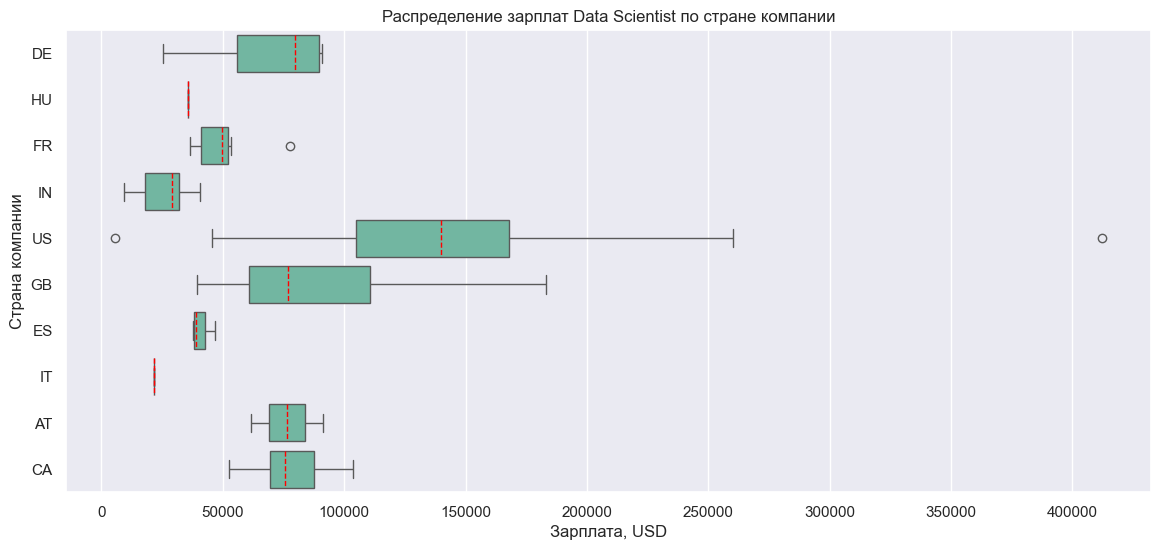

In [50]:
top_countries = data[data['job_title'] == 'Data Scientist']['company_location'].value_counts().head(10).index

data_ds = data[
    (data['job_title'] == 'Data Scientist') &
    (data['company_location'].isin(top_countries))
]

plt.figure(figsize=(14, 6))
sns.boxplot(data=data_ds, x='salary_in_usd', y='company_location',
            orient='h', medianprops={"color": "red", "linestyle": '--'})
plt.xlabel('Зарплата, USD')
plt.ylabel('Страна компании')
plt.title('Распределение зарплат Data Scientist по стране компании')
plt.show()

Вывод : Зарплаты Data Scientist заметно различаются по стране компании: самые высокие значения наблюдаются в США и Великобритании, а самые низкие — в Индии и ряде европейских стран. Это может указывать на связь между страной компании и уровнем оплаты труда. 

##### Статистический анализ

**Сформулируем нулевую и альтернативные гипотезы**

H0: распределения зарплат Data Scientist в компаниях из разных стран одинаковы.

H1: хотя бы в одной стране распределение отличается.

Будем использовать **критерий Краскела–Уоллиса**

In [53]:
groups = []
for country, group in data_ds.groupby('company_location'):
    print(country + ':')
    result = stats.shapiro(group['salary_in_usd'])
    decision_normality(result[1])
    groups.append(group['salary_in_usd'].values)

stat, p = stats.kruskal(*groups)
decision_hypothesis(p)

CA:
p-value = 0.997
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
DE:
p-value = 0.148
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
ES:
p-value = 0.184
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
FR:
p-value = 0.128
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
GB:
p-value = 0.277
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
IN:
p-value = 0.761
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
US:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


Вывод : Для большинства стран распределение зарплат Data Scientist не отличается от нормального, однако для США распределение является ненормальным. Поэтому при сравнении зарплат по странам нельзя использовать параметрические методы, и нулевая гипотеза отвергается: страна компании статистически значимо влияет на уровень зарплаты.

#### Влияние удалённой работы на зарплату 

In [54]:
df = data[['remote_ratio', 'salary_in_usd']].dropna().copy()

mapping = {0: 'No remote', 50: 'Hybrid', 100: 'Full remote'}
df = df[df['remote_ratio'].isin(mapping.keys())]
df['remote_group'] = df['remote_ratio'].map(mapping)

summary = df.groupby('remote_group')['salary_in_usd'].agg(['count', 'mean', 'median', 'std']).round(2)
summary

,count,mean,median,std
remote_group,,,,
Full remote,381,122457.45,115000.0,72710.84
Hybrid,99,80823.03,69999.0,57353.09
No remote,127,106354.62,99000.0,67724.54


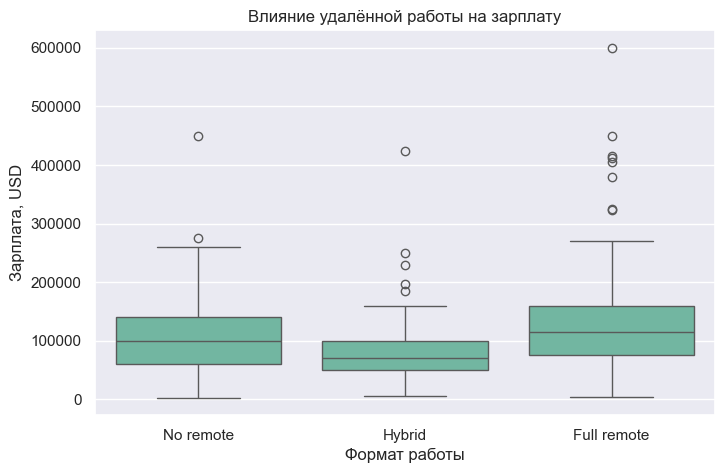

In [55]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='remote_group', y='salary_in_usd',
            order=['No remote', 'Hybrid', 'Full remote'])
plt.xlabel('Формат работы')
plt.ylabel('Зарплата, USD')
plt.title('Влияние удалённой работы на зарплату')
plt.show()

Вывод : Самая высокая средняя зарплата у полностью удалённых сотрудников — 122 457.45 USD. У сотрудников без удалённой работы средняя зарплата ниже — 106 354.62 USD, а у гибридного формата она минимальна — 80 823.03 USD.

##### Статистический анализ

**Сформулируем нулевую и альтернативные гипотезы**

H0: зарплаты при разных форматах работы одинаковы.

H1: хотя бы в одной группе зарплата отличается.

Будем использовать **критерий Краскела–Уоллиса**

In [56]:
groups = [group['salary_in_usd'].values for _, group in df.groupby('remote_group')]
stat, p = stats.kruskal(*groups)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


Вывод : Удалённая работа статистически значимо связана с уровнем зарплаты: у полностью удалённых сотрудников средняя зарплата выше, чем у сотрудников без удалённой работы, а у гибридного формата — ниже. Следовательно, формат работы оказывает влияние на зарплату. 